# Q1 Circular Polarization Switching Scan

This notebook compares two ways of switching a Q1 drive between circular polarization components:

- strict square-wave switching between sigma+ and sigma-
- resonant EOM-style polarization modulation that continuously moves through the intermediate polarization states

The baseline traces use a 100 us interaction time, a Rabi rate of 1 Gamma, and a polarization switching frequency of 1 MHz. The scan compares final photon count versus Rabi rate and switching frequency, both expressed in units of Gamma.

In [1]:
from __future__ import annotations

from time import perf_counter

import matplotlib.pyplot as plt
import numpy as np

from centrex_tlf import couplings, hamiltonian, lindblad, transitions
from centrex_tlf.lindblad import (
    LindbladParameters,
    grid_scan,
    prepare_lindblad_problem,
    resonant_polarization_modulation,
    square_wave,
)
from centrex_tlf.lindblad.solve import solve_lindblad

plt.rcParams.update({"font.size": 14})

## Configuration

The notebook uses `Q1_F1_3o2_F1` by default because that is the Q1 transition used by the existing Q1 Lindblad examples. Change `transition` here to use another available Q1 transition.

In [2]:
Gamma = hamiltonian.Γ

transition = transitions.Q1_F1_3o2_F1
t_final = 100e-6
t_eval = np.linspace(0.0, t_final, 2001)

baseline_rabi_over_gamma = 1.0
baseline_f_pol_hz = 1.0e6
baseline_omega_pol = 2 * np.pi * baseline_f_pol_hz
mod_depth = np.pi / 2

n_scan = 25
rabi_over_gamma_axis = np.linspace(0.1, 5.0, n_scan)
omega_pol_over_gamma_axis = np.linspace(0.05, 5.0, n_scan)

scan_saveat = np.linspace(0.0, t_final, 1001)
polarization_plot_cycles = 4

solver_options = {
    "solver": "dopri5",
    "execution_mode": "expanded_sparse",
    "dt": 1e-10,
    "reltol": 1e-6,
    "abstol": 1e-8,
    "maxiters": 2_000_000,
}

print(
    {
        "Gamma_rad_s": Gamma,
        "baseline_Omega_over_Gamma": baseline_rabi_over_gamma,
        "baseline_f_pol_MHz": baseline_f_pol_hz / 1e6,
        "baseline_omega_pol_over_Gamma": baseline_omega_pol / Gamma,
        "interaction_time_us": t_final * 1e6,
        "scan_shape": (n_scan, n_scan),
        "baseline_save_points": len(t_eval),
        "scan_output": "Rust photon_integral",
        "scan_save_points": len(scan_saveat),
    }
)

{'Gamma_rad_s': 9801769.079200154, 'baseline_Omega_over_Gamma': 1.0, 'baseline_f_pol_MHz': 1.0, 'baseline_omega_pol_over_Gamma': 0.6410256410256411, 'interaction_time_us': 100.0, 'scan_shape': (25, 25), 'baseline_save_points': 2001, 'scan_output': 'Rust photon_integral', 'scan_save_points': 1001}


## Build the OBE System

The transition is generated with two circular polarization symbols, one for sigma+ and one for sigma-. Both switching models use the same OBE system, initial state, solver settings, and scan axes.

In [3]:
transition_selectors = couplings.generate_transition_selectors(
    [transition],
    [[couplings.polarization_σp, couplings.polarization_σm]],
)
selector = transition_selectors[0]

setup_start = perf_counter()
system = lindblad.generate_OBE_system_transitions(
    [transition],
    transition_selectors,
    qn_compact=True,
    method="matrix",
)
setup_seconds = perf_counter() - setup_start

omega_symbol = getattr(selector, "Ω")
delta_symbol = getattr(selector, "δ")
pol_symbols = list(selector.polarization_symbols)
sigma_p_symbol, sigma_m_symbol = pol_symbols

print(
    {
        "transition": repr(transition),
        "n_states": len(system.QN),
        "n_ground": len(system.ground),
        "n_excited": len(system.excited),
        "coupling_symbol": str(omega_symbol),
        "detuning_symbol": str(delta_symbol),
        "polarization_symbols": [str(symbol) for symbol in pol_symbols],
        "setup_seconds": setup_seconds,
    }
)

{'transition': "OpticalTransition(Q(1) F1'=3/2 F'=1)", 'n_states': 16, 'n_ground': 40, 'n_excited': 3, 'coupling_symbol': 'Ω0', 'detuning_symbol': 'δ0', 'polarization_symbols': ['Pσp0', 'Pσm0'], 'setup_seconds': 0.8045824998989701}


## Parameters

The square-wave model jumps between pure sigma+ and pure sigma-. The resonant model uses the scalar helper twice, with opposite modulation depths, to produce complementary circular components.

In [4]:
def base_symbol_values(system, default=0.0):
    values = {str(symbol): default for symbol in system.H_symbolic.free_symbols}
    for symbol in system.coupling_symbols:
        values[str(symbol)] = Gamma
    for group in system.polarization_symbols:
        symbols = group if isinstance(group, (list, tuple)) else [group]
        for symbol in symbols:
            values.pop(str(symbol), None)
    return values


def make_square_parameters():
    params = LindbladParameters()
    base_values = base_symbol_values(system)
    parameter_objects = {name: params.real(name, value) for name, value in base_values.items()}

    rabi = parameter_objects[str(omega_symbol)]
    detuning = parameter_objects[str(delta_symbol)]
    omega_pol = params.real("omega_pol", baseline_omega_pol)
    time = params.time()

    params.bind(omega_symbol, rabi, finalize=False)
    params.bind(delta_symbol, detuning, finalize=False)
    sigma_p = square_wave(time, omega_pol, 0.0)
    params.bind(sigma_p_symbol, sigma_p, finalize=False)
    params.bind(sigma_m_symbol, 1.0 - sigma_p, finalize=True)
    return params, rabi, omega_pol


def make_resonant_parameters():
    params = LindbladParameters()
    base_values = base_symbol_values(system)
    parameter_objects = {name: params.real(name, value) for name, value in base_values.items()}

    rabi = parameter_objects[str(omega_symbol)]
    detuning = parameter_objects[str(delta_symbol)]
    omega_pol = params.real("omega_pol", baseline_omega_pol)
    gamma_mod = params.real("mod_depth", mod_depth)
    time = params.time()

    params.bind(omega_symbol, rabi, finalize=False)
    params.bind(delta_symbol, detuning, finalize=False)
    params.bind(
        sigma_p_symbol,
        resonant_polarization_modulation(time, -gamma_mod, omega_pol),
        finalize=False,
    )
    params.bind(
        sigma_m_symbol,
        resonant_polarization_modulation(time, gamma_mod, omega_pol),
        finalize=True,
    )
    return params, rabi, omega_pol


square_params, square_rabi_parameter, square_omega_pol_parameter = make_square_parameters()
resonant_params, resonant_rabi_parameter, resonant_omega_pol_parameter = make_resonant_parameters()

prepared_square = prepare_lindblad_problem(
    system,
    square_params,
    backend="rust",
    hamiltonian_representation="decomposed",
)
prepared_resonant = prepare_lindblad_problem(
    system,
    resonant_params,
    backend="rust",
    hamiltonian_representation="decomposed",
)

print(
    {
        "square_slots": list(prepared_square.parameter_graph["slot_names"]),
        "resonant_slots": list(prepared_resonant.parameter_graph["slot_names"]),
    }
)

{'square_slots': ['Ω0', 'δ0', 'omega_pol', 'Pσp0', 'Pσm0'], 'resonant_slots': ['Ω0', 'δ0', 'omega_pol', 'mod_depth', 'Pσp0', 'Pσm0']}


## Initial State and State Labels

The initial density matrix is uniform over the driven Q1 ground manifold in the compacted system. Plot labels use each compact state's dominant basis component and the string formatting from `states.py`.

In [5]:
def compact_state_label(state):
    largest = getattr(state, "largest", state)
    if hasattr(largest, "state_string_custom"):
        return largest.state_string_custom(["J", "F1", "F", "mF"])
    if hasattr(largest, "state_string"):
        return largest.state_string()
    return repr(state)


def dominant_electronic_name(state):
    largest = getattr(state, "largest", state)
    electronic = getattr(largest, "electronic_state", None)
    return None if electronic is None else electronic.name


def dominant_J(state):
    largest = getattr(state, "largest", state)
    return getattr(largest, "J", None)


n_states = len(system.QN)
ground_indices = np.array(
    [
        idx
        for idx, state in enumerate(system.QN)
        if dominant_electronic_name(state) == "X" and dominant_J(state) == transition.J_ground
    ],
    dtype=int,
)
excited_indices = np.array(
    [idx for idx, state in enumerate(system.QN) if dominant_electronic_name(state) == "B"],
    dtype=int,
)

rho0 = np.zeros((n_states, n_states), dtype=np.complex128)
rho0[ground_indices, ground_indices] = 1.0 / len(ground_indices)

state_labels = [compact_state_label(state) for state in system.QN]
ground_labels = [state_labels[idx] for idx in ground_indices]
excited_labels = [state_labels[idx] for idx in excited_indices]

print(
    {
        "trace_rho0": float(np.trace(rho0).real),
        "ground_indices": ground_indices.tolist(),
        "excited_indices": excited_indices.tolist(),
    }
)

{'trace_rho0': 1.0, 'ground_indices': [0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11], 'excited_indices': [13, 14, 15]}


## Baseline Evolution

These traces use `Omega = 1 Gamma`, `f_pol = 1 MHz`, and a 100 us interaction time. Photon counts are integrated from the saved excited-state population, so the baseline and scan save grids are intentionally denser than the population plots visually require.

In [6]:
baseline_square = solve_lindblad(
    prepared_square,
    rho0,
    (0.0, t_final),
    saveat=t_eval,
    output="populations",
    **solver_options,
)
baseline_resonant = solve_lindblad(
    prepared_resonant,
    rho0,
    (0.0, t_final),
    saveat=t_eval,
    output="populations",
    **solver_options,
)

square_populations = np.asarray(baseline_square.values)
resonant_populations = np.asarray(baseline_resonant.values)

square_excited_total = square_populations[:, excited_indices].sum(axis=1)
resonant_excited_total = resonant_populations[:, excited_indices].sum(axis=1)
square_photons = Gamma * np.concatenate(
    [
        [0.0],
        np.cumsum(0.5 * (square_excited_total[1:] + square_excited_total[:-1]) * np.diff(t_eval)),
    ]
)
resonant_photons = Gamma * np.concatenate(
    [
        [0.0],
        np.cumsum(
            0.5 * (resonant_excited_total[1:] + resonant_excited_total[:-1]) * np.diff(t_eval)
        ),
    ]
)

print(
    {
        "square_final_photons": float(square_photons[-1]),
        "resonant_final_photons": float(resonant_photons[-1]),
    }
)

{'square_final_photons': 2.5140467432196503, 'resonant_final_photons': 2.8959506314436574}


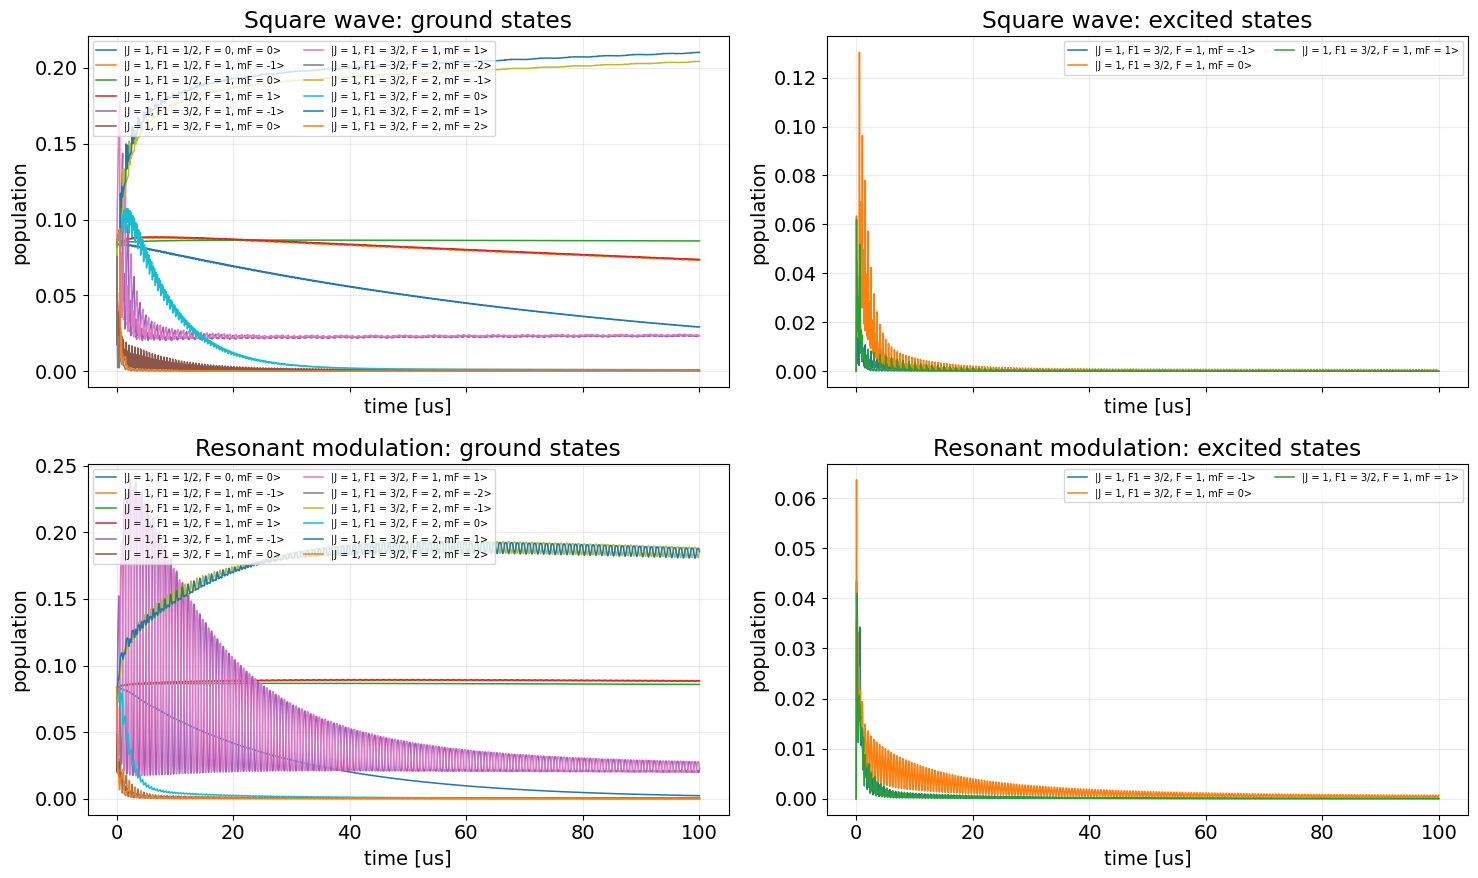

In [7]:
def plot_population_panel(ax, t, populations, indices, labels, title):
    for idx, label in zip(indices, labels):
        ax.plot(t * 1e6, populations[:, idx], lw=1.1, label=label)
    ax.set_title(title)
    ax.set_xlabel("time [us]")
    ax.set_ylabel("population")
    ax.grid(alpha=0.25)
    ax.legend(fontsize=7, ncols=2, loc="best")


fig, axes = plt.subplots(2, 2, figsize=(15, 9), sharex=True)
plot_population_panel(
    axes[0, 0],
    t_eval,
    square_populations,
    ground_indices,
    ground_labels,
    "Square wave: ground states",
)
plot_population_panel(
    axes[0, 1],
    t_eval,
    square_populations,
    excited_indices,
    excited_labels,
    "Square wave: excited states",
)
plot_population_panel(
    axes[1, 0],
    t_eval,
    resonant_populations,
    ground_indices,
    ground_labels,
    "Resonant modulation: ground states",
)
plot_population_panel(
    axes[1, 1],
    t_eval,
    resonant_populations,
    excited_indices,
    excited_labels,
    "Resonant modulation: excited states",
)
fig.tight_layout()

{'square_intensity_sum_range': (1.0, 1.0), 'resonant_intensity_sum_range': (0.9999999999999997, 1.0000000000000004), 'square_mean_sigma_plus': 0.5, 'resonant_mean_sigma_plus': 0.5000000000000001}


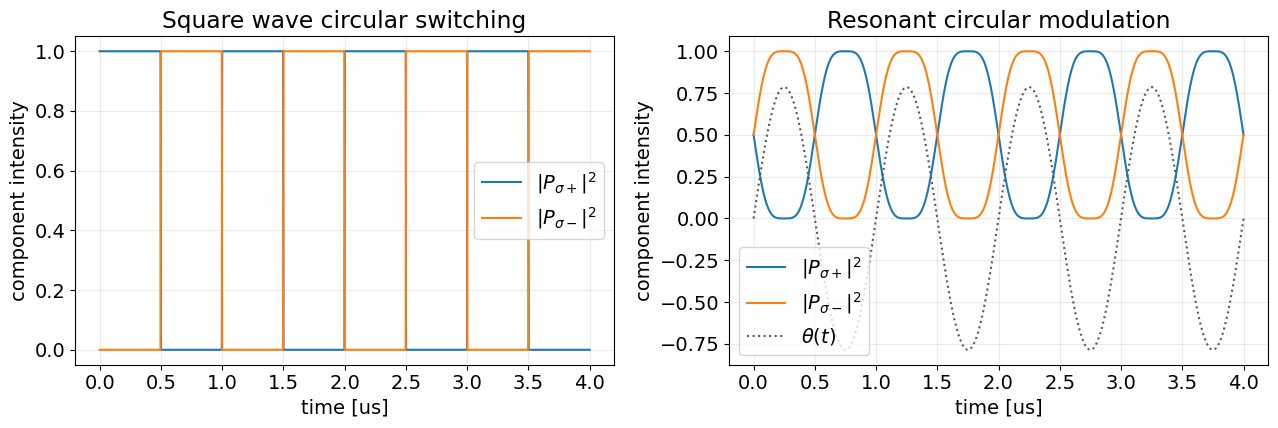

In [8]:
polarization_t_eval = np.linspace(
    0.0,
    min(t_final, polarization_plot_cycles / baseline_f_pol_hz),
    1200,
)
theta = 0.5 * mod_depth * np.sin(baseline_omega_pol * polarization_t_eval)
square_sigma_p_intensity = np.asarray(
    [square_wave(t, baseline_omega_pol, 0.0) for t in polarization_t_eval], dtype=float
)
square_sigma_m_intensity = 1.0 - square_sigma_p_intensity
resonant_sigma_p = np.asarray(
    [
        resonant_polarization_modulation(t, -mod_depth, baseline_omega_pol)
        for t in polarization_t_eval
    ]
)
resonant_sigma_m = np.asarray(
    [
        resonant_polarization_modulation(t, mod_depth, baseline_omega_pol)
        for t in polarization_t_eval
    ]
)
resonant_sigma_p_intensity = np.abs(resonant_sigma_p) ** 2
resonant_sigma_m_intensity = np.abs(resonant_sigma_m) ** 2

print(
    {
        "square_intensity_sum_range": (
            float((square_sigma_p_intensity + square_sigma_m_intensity).min()),
            float((square_sigma_p_intensity + square_sigma_m_intensity).max()),
        ),
        "resonant_intensity_sum_range": (
            float((resonant_sigma_p_intensity + resonant_sigma_m_intensity).min()),
            float((resonant_sigma_p_intensity + resonant_sigma_m_intensity).max()),
        ),
        "square_mean_sigma_plus": float(square_sigma_p_intensity.mean()),
        "resonant_mean_sigma_plus": float(resonant_sigma_p_intensity.mean()),
    }
)

fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))
axes[0].plot(polarization_t_eval * 1e6, square_sigma_p_intensity, label=r"$|P_{\sigma+}|^2$")
axes[0].plot(polarization_t_eval * 1e6, square_sigma_m_intensity, label=r"$|P_{\sigma-}|^2$")
axes[0].set_title("Square wave circular switching")
axes[0].set_xlabel("time [us]")
axes[0].set_ylabel("component intensity")
axes[0].grid(alpha=0.25)
axes[0].legend()

axes[1].plot(polarization_t_eval * 1e6, resonant_sigma_p_intensity, label=r"$|P_{\sigma+}|^2$")
axes[1].plot(polarization_t_eval * 1e6, resonant_sigma_m_intensity, label=r"$|P_{\sigma-}|^2$")
axes[1].plot(polarization_t_eval * 1e6, theta, color="0.35", ls=":", label=r"$\theta(t)$")
axes[1].set_title("Resonant circular modulation")
axes[1].set_xlabel("time [us]")
axes[1].set_ylabel("component intensity")
axes[1].grid(alpha=0.25)
axes[1].legend()
fig.tight_layout()

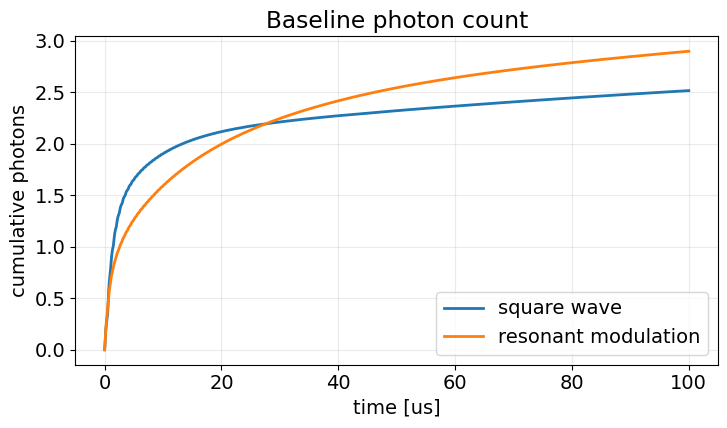

In [9]:
fig, ax = plt.subplots(figsize=(7.5, 4.5))
ax.plot(t_eval * 1e6, square_photons, lw=2, label="square wave")
ax.plot(t_eval * 1e6, resonant_photons, lw=2, label="resonant modulation")
ax.set_xlabel("time [us]")
ax.set_ylabel("cumulative photons")
ax.set_title("Baseline photon count")
ax.grid(alpha=0.25)
ax.legend()
fig.tight_layout()

## Parameter Scan

The scan uses Rust's built-in integral output. The integral weights are `Gamma` on the excited-state populations, so each trajectory returns the final photon count directly. `saveat` still controls the trapezoid sampling used by the Rust output accumulator.

In [10]:
def photon_counts_from_integral(result, grid_shape):
    return np.asarray(result.values, dtype=float).reshape(grid_shape)


photon_integral_weights = [(int(idx), float(Gamma)) for idx in excited_indices]
scan_shape = (len(rabi_over_gamma_axis), len(omega_pol_over_gamma_axis))

square_scan_start = perf_counter()
square_scan = grid_scan(
    prepared_square,
    rho0,
    (0.0, t_final),
    scan={
        square_rabi_parameter: Gamma * rabi_over_gamma_axis,
        square_omega_pol_parameter: Gamma * omega_pol_over_gamma_axis,
    },
    output="photon_integral",
    integral_weights=photon_integral_weights,
    saveat=scan_saveat,
    output_when="saveat",
    collect_stats=True,
    **solver_options,
)
square_scan_seconds = perf_counter() - square_scan_start

resonant_scan_start = perf_counter()
resonant_scan = grid_scan(
    prepared_resonant,
    rho0,
    (0.0, t_final),
    scan={
        resonant_rabi_parameter: Gamma * rabi_over_gamma_axis,
        resonant_omega_pol_parameter: Gamma * omega_pol_over_gamma_axis,
    },
    output="photon_integral",
    integral_weights=photon_integral_weights,
    saveat=scan_saveat,
    output_when="saveat",
    collect_stats=True,
    **solver_options,
)
resonant_scan_seconds = perf_counter() - resonant_scan_start

square_photon_grid = photon_counts_from_integral(square_scan, scan_shape)
resonant_photon_grid = photon_counts_from_integral(resonant_scan, scan_shape)
difference_grid = resonant_photon_grid - square_photon_grid

print(
    {
        "square_scan_seconds": square_scan_seconds,
        "resonant_scan_seconds": resonant_scan_seconds,
        "square_photon_range": (float(square_photon_grid.min()), float(square_photon_grid.max())),
        "resonant_photon_range": (
            float(resonant_photon_grid.min()),
            float(resonant_photon_grid.max()),
        ),
    }
)

{'square_scan_seconds': 20.07006060006097, 'resonant_scan_seconds': 10.540646099951118, 'square_photon_range': (1.2142377064980756, 3.1507500955522234), 'resonant_photon_range': (0.3585683321266069, 3.167916567778967)}


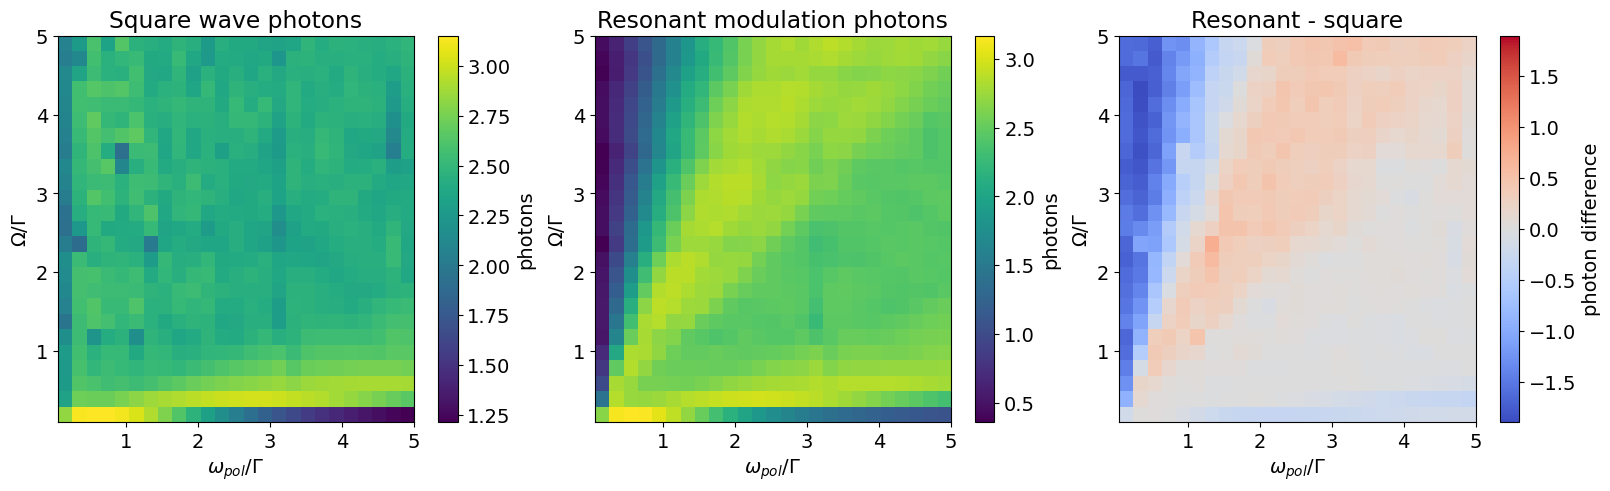

In [11]:
def heatmap(ax, data, title, *, cmap="viridis"):
    image = ax.imshow(
        data,
        origin="lower",
        aspect="auto",
        extent=[
            omega_pol_over_gamma_axis[0],
            omega_pol_over_gamma_axis[-1],
            rabi_over_gamma_axis[0],
            rabi_over_gamma_axis[-1],
        ],
        cmap=cmap,
    )
    ax.set_title(title)
    ax.set_xlabel(r"$\omega_{pol} / \Gamma$")
    ax.set_ylabel(r"$\Omega / \Gamma$")
    return image


fig, axes = plt.subplots(1, 3, figsize=(16, 4.8), constrained_layout=True)
im0 = heatmap(axes[0], square_photon_grid, "Square wave photons")
fig.colorbar(im0, ax=axes[0], label="photons")
im1 = heatmap(axes[1], resonant_photon_grid, "Resonant modulation photons")
fig.colorbar(im1, ax=axes[1], label="photons")
limit = np.max(np.abs(difference_grid))
im2 = heatmap(axes[2], difference_grid, "Resonant - square", cmap="coolwarm")
im2.set_clim(-limit, limit)
fig.colorbar(im2, ax=axes[2], label="photon difference")

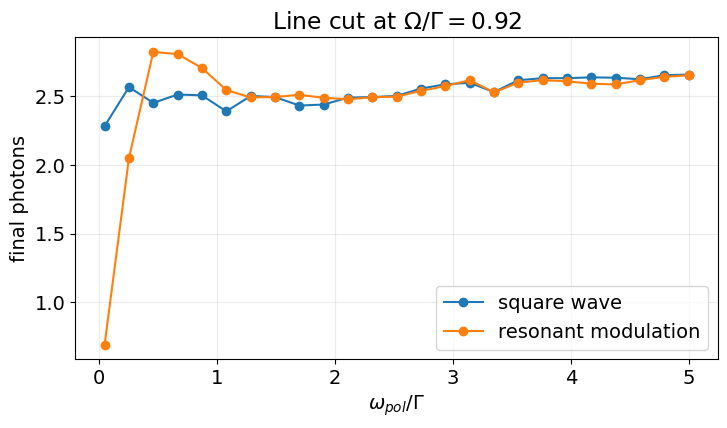

In [12]:
rabi_line_index = int(np.argmin(np.abs(rabi_over_gamma_axis - 1.0)))

fig, ax = plt.subplots(figsize=(7.5, 4.5))
ax.plot(
    omega_pol_over_gamma_axis,
    square_photon_grid[rabi_line_index],
    marker="o",
    label="square wave",
)
ax.plot(
    omega_pol_over_gamma_axis,
    resonant_photon_grid[rabi_line_index],
    marker="o",
    label="resonant modulation",
)
ax.set_xlabel(r"$\omega_{pol} / \Gamma$")
ax.set_ylabel("final photons")
ax.set_title(rf"Line cut at $\Omega / \Gamma = {rabi_over_gamma_axis[rabi_line_index]:.2f}$")
ax.grid(alpha=0.25)
ax.legend()
fig.tight_layout()